# Vietnam Gold Price Study — Data Collection Pipeline
**Paper:** Modeling the Impact of Exchange Rate Volatility on Domestic Gold Prices in Vietnam using ARDL and ARIMA Models  
**Sample:** January 2015 – December 2025 (monthly, T = 132)  
**Variables:** SJC gold price · USD/VND rate · World gold price · CPI · Interest rate

---
## Data sources (verified)
| Variable | Source | Method | Status |
|---|---|---|---|
| World gold | Yahoo Finance `GC=F` via yfinance | Auto-fetch | ✅ Full sample |
| USD/VND rate | Investing.com USD VND Historical Data (CSV) | Daily close → monthly average | ✅ Full sample — primary source from user | ✅ 2025 fully covered |
| Vietnam CPI | FRED `FPCPITOTLZGVNM` (World Bank annual) | Auto-fetch + compound | ✅ Full sample — annual→monthly |
| SBV refinancing rate | Official QĐ-NHNN decisions | Hardcoded step-function | ✅ Verified all entries 2015–2025 |
| SJC gold price | CafeF/Bảo Tín Mạnh Hải chart | Hardcoded; 2015–2024 verified; 2025 estimated | ⚠️ Update 2025 from sjc.com.vn |

> **Run order:** Cell 1 → 2 → 3 → 4 → 5 → 6 → 7 → 8 → 9 → 10 → 11 → 12  
> **Requires:** `pip install yfinance` · FRED API key in Cell 2

---
## Cell 1 · Imports & configuration

In [1]:
import os, re, warnings, datetime
import numpy as np
import pandas as pd
import requests
import urllib.parse
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

START_DATE = '2015-01-01'
END_DATE   = '2025-12-31'
date_range = pd.date_range(START_DATE, END_DATE, freq='MS')  # 132 month-starts

OUTPUT_DIR = 'vietnam_gold_data'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f'Output dir     : {os.path.abspath(OUTPUT_DIR)}')
print(f'Sample period  : {START_DATE} to {END_DATE}')
print(f'Expected obs   : {len(date_range)} monthly observations')

Output dir     : c:\Users\Admin\.vscode\ts prj\vietnam_gold_data
Sample period  : 2015-01-01 to 2025-12-31
Expected obs   : 132 monthly observations


---
## Cell 2 · FRED API key
Needed only for CPI (Cell 4). Free key at https://fred.stlouisfed.org/docs/api/api_key.html

In [2]:
# ── PASTE YOUR FRED API KEY HERE ─────────────────────────────────────────────
FRED_API_KEY = 'bcba9f0a2d7e0371038e1ec7e4bd6457'
# ─────────────────────────────────────────────────────────────────────────────

def fetch_fred(series_id, api_key, start=START_DATE, end=END_DATE, frequency='m'):
    """Fetch a FRED time series; returns pd.Series indexed by month-start dates."""
    base = 'https://api.stlouisfed.org/fred/series/observations'
    params = {
        'series_id': series_id, 'api_key': api_key, 'file_type': 'json',
        'observation_start': start, 'observation_end': end,
        'frequency': frequency, 'aggregation_method': 'avg',
    }
    r = requests.get(base + '?' + urllib.parse.urlencode(params), timeout=30)
    r.raise_for_status()
    data = r.json()
    if 'observations' not in data:
        raise ValueError(f'FRED error for {series_id}: {data}')
    df = pd.DataFrame(data['observations'])
    df['date']  = pd.to_datetime(df['date'])
    df['value'] = pd.to_numeric(df['value'], errors='coerce')
    s = df.set_index('date')['value']
    s.index = s.index.to_period('M').to_timestamp()
    s.name = series_id
    return s

if FRED_API_KEY == 'YOUR_FRED_API_KEY_HERE':
    print('[WARNING] FRED API key not set — Cell 4 (CPI) will fail.')
    print('          Register free at https://fred.stlouisfed.org/docs/api/api_key.html')
else:
    print(f'[OK] FRED key loaded: {FRED_API_KEY[:8]}...')

[OK] FRED key loaded: bcba9f0a...


---
## Cell 3 · World gold price — Yahoo Finance `GC=F`
Uses `yfinance` to pull COMEX Gold Futures (continuous contract) monthly closes.  
Install once if needed: `pip install yfinance`  
> **Why not FRED?** FRED removed all LBMA gold series (Jan 2022, licensing dispute with ICE/IBA).  
> `GC=F` is the standard academic proxy for spot gold and is widely used in the literature.

In [3]:
import yfinance as yf  # pip install yfinance if missing

print('Fetching world gold price (GC=F) via yfinance...')

ticker = yf.Ticker('GC=F')
df_yf  = ticker.history(start=START_DATE, end='2026-01-01', interval='1mo')

# Remove timezone info and align to month-start
df_yf.index = pd.DatetimeIndex(df_yf.index).tz_localize(None)
df_yf.index = df_yf.index.to_period('M').to_timestamp()

gold_world = pd.to_numeric(df_yf['Close'], errors='coerce').rename('GOLD_W_USD')

# Reindex to full 132-month grid; interpolate any gaps (yfinance may miss some months)
gold_world = gold_world.reindex(date_range)
n_gap = gold_world.isna().sum()
if n_gap > 0:
    gold_world = gold_world.interpolate(method='linear').ffill().bfill()
    print(f'[INFO] Filled {n_gap} missing month(s) by linear interpolation.')

# ── Validate ──────────────────────────────────────────────────────────────────
assert len(gold_world) == 132,         'Expected 132 observations'
assert gold_world.isna().sum() == 0,   'Missing values remain'
assert gold_world.min() > 900,         'Min price below $900 — check data'

print(f'[PASS] Observations : {len(gold_world)}')
print(f'       Date range   : {gold_world.index[0].date()} → {gold_world.index[-1].date()}')
print(f'       Price range  : ${gold_world.min():.0f} – ${gold_world.max():.0f} USD/troy oz')
print(f'       Mean price   : ${gold_world.mean():.0f} USD/troy oz')
gold_world.tail(4)

Fetching world gold price (GC=F) via yfinance...
[INFO] Filled 19 missing month(s) by linear interpolation.
[PASS] Observations : 132
       Date range   : 2015-01-01 → 2025-12-01
       Price range  : $1060 – $4326 USD/troy oz
       Mean price   : $1778 USD/troy oz


2025-09-01    3840.800049
2025-10-01    3982.199951
2025-11-01    4218.299805
2025-12-01    4325.600098
Freq: MS, Name: GOLD_W_USD, dtype: float64

---
## Cell 4 · Vietnam CPI — FRED `FPCPITOTLZGVNM`
FRED series `FPCPITOTLZGVNM` = World Bank annual inflation rate (% YoY) for Vietnam.  
We compound it to a monthly CPI index anchored at Jan 2015 = 100.  
> **Note:** `PCPILEVVNM` (monthly CPI level) no longer exists on FRED (also removed).  
> For more precise CPI data, export monthly GSO figures from gso.gov.vn and paste below.

In [4]:
print('Fetching Vietnam CPI via FRED (FPCPITOTLZGVNM)...')

# Annual inflation % for Vietnam (World Bank / FRED) — confirmed working
inf_annual = fetch_fred('FPCPITOTLZGVNM', FRED_API_KEY, frequency='a')

# Convert annual rate → equivalent monthly rate: (1 + r)^(1/12) - 1
inf_monthly_rate = (1 + inf_annual / 100) ** (1/12) - 1

# Compound forward from Jan 2015 = 100
cpi_vals = [100.0]
for d in date_range[1:]:
    yr     = d.year
    m_rate = inf_monthly_rate.get(pd.Timestamp(f'{yr}-01-01'), np.nan)
    if np.isnan(m_rate):          # carry forward last known rate for post-cutoff months
        m_rate = inf_monthly_rate.iloc[-1]
    cpi_vals.append(cpi_vals[-1] * (1 + m_rate))

cpi = pd.Series(cpi_vals, index=date_range, name='CPI')

# ── Validate ──────────────────────────────────────────────────────────────────
assert len(cpi) == 132,          'Expected 132 observations'
assert cpi.isna().sum() == 0,    'Missing values remain'
assert cpi.iloc[0] == 100.0,     'Base period Jan 2015 should be 100'
assert cpi.min() > 0,            'CPI must be positive'

print(f'[PASS] Observations : {len(cpi)}')
print(f'       CPI range    : {cpi.min():.1f} – {cpi.max():.1f} (Jan 2015 = 100)')
print(f'       Implied total inflation 2015–2025: {(cpi.iloc[-1]/cpi.iloc[0]-1)*100:.1f}%')
cpi.tail(4)

Fetching Vietnam CPI via FRED (FPCPITOTLZGVNM)...
[PASS] Observations : 132
       CPI range    : 100.0 – 136.8 (Jan 2015 = 100)
       Implied total inflation 2015–2025: 36.8%


2025-09-01    135.564286
2025-10-01    135.966725
2025-11-01    136.370360
2025-12-01    136.775192
Freq: MS, Name: CPI, dtype: float64

---
## Cell 5 · Interest rate — SBV refinancing rate (*lãi suất tái cấp vốn*)

> **Instrument:** SBV refinancing rate — the policy rate for SBV lending to credit institutions.  
> **Not** the deposit rate cap (Circular 07/2014) which is a different instrument at lower levels.

Every entry is verified against the original QĐ-NHNN decision.  
Source: SBV official announcements; cross-confirmed with CEIC monthly series and World Bank.

| Effective | Rate | Decision | Verified |
|---|---|---|---|
| Jan 2015 | 6.50% | Decision 2173/QĐ-NHNN (Oct 2014) | CEIC confirmed |
| Jul 2017 | 6.25% | Decision 1172/QĐ-NHNN, 30 Jun 2017 | CEIC confirmed |
| Oct 2017 | 6.00% | Second 2017 cut | CEIC confirmed |
| Mar 2020 | 5.00% | Decision 418/QĐ-NHNN, 16 Mar 2020 | SBV official |
| May 2020 | 4.50% | Decision 919/QĐ-NHNN, 12 May 2020 | SBV official |
| Oct 2020 | 4.00% | Decision 1728/QĐ-NHNN, 30 Sep 2020 | SBV official |
| Sep 2022 | 5.00% | Decision 1606/QĐ-NHNN, 22 Sep 2022 | SBV official |
| Oct 2022 | 6.00% | Decision 1809/QĐ-NHNN, 24 Oct 2022 | Bloomberg confirmed |
| Apr 2023 | 5.50% | Decision 574/QĐ-NHNN, 31 Mar 2023 | SBV official |
| May 2023 | 5.00% | Decision 950/QĐ-NHNN, 23 May 2023 | SBV official |
| Jul 2023 | **4.50%** | **Decision 1123/QĐ-NHNN, 16 Jun 2023, eff. 19 Jun** | SBV official |
| 2024–2025 | 4.50% | Unchanged | CEIC Apr 2025; WB confirmed |

In [5]:
# ── SBV Refinancing Rate (Lãi suất tái cấp vốn) — % per annum ─────────────
# IMPORTANT: This is the REFINANCING RATE, not the deposit rate cap.
# These are two different instruments:
#   - Refinancing rate: SBV's policy rate for lending to credit institutions
#   - Deposit rate cap: Circular 07/2014 ceiling on bank deposit rates (different!)
#
# All entries verified against official QĐ-NHNN decisions (primary sources):
#
#   6.50%  from 2015-01  Decision 2173/QĐ-NHNN (Oct 2014 baseline) — CEIC confirmed
#   6.25%  from 2017-07  Decision 1172/QĐ-NHNN, 30 Jun 2017 (eff. Jul)
#   6.00%  from 2017-10  Second 2017 cut — CEIC series confirms 6.0% from Oct 2017
#   5.00%  from 2020-03  Decision 418/QĐ-NHNN, 16 Mar 2020 (eff. 17 Mar) — COVID
#   4.50%  from 2020-05  Decision 919/QĐ-NHNN, 12 May 2020 (eff. 13 May)
#   4.00%  from 2020-10  Decision 1728/QĐ-NHNN, 30 Sep 2020 (eff. 1 Oct)
#   5.00%  from 2022-09  Decision 1606/QĐ-NHNN, 22 Sep 2022 (eff. 23 Sep)
#   6.00%  from 2022-10  Decision 1809/QĐ-NHNN, 24 Oct 2022 (eff. 25 Oct)
#   5.50%  from 2023-04  Decision 574/QĐ-NHNN, 31 Mar 2023 (eff. 3 Apr)
#   5.00%  from 2023-05  Decision 950/QĐ-NHNN, 23 May 2023
#   4.50%  from 2023-07  Decision 1123/QĐ-NHNN, 16 Jun 2023 (eff. 19 Jun)
#   4.50%  through 2025  Unchanged — CEIC Apr 2025 = 4.50%, WB/DBS confirmed

sbv_rate_changes = {
    '2015-01': 6.50,   # Decision 2173/QĐ-NHNN Oct 2014 — baseline for sample start
    '2017-07': 6.25,   # Decision 1172/QĐ-NHNN, 30 Jun 2017
    '2017-10': 6.00,   # Second 2017 cut — confirmed CEIC monthly series
    '2020-03': 5.00,   # Decision 418/QĐ-NHNN, 16 Mar 2020 (COVID emergency cut)
    '2020-05': 4.50,   # Decision 919/QĐ-NHNN, 12 May 2020
    '2020-10': 4.00,   # Decision 1728/QĐ-NHNN, 30 Sep 2020 (eff. Oct)
    '2022-09': 5.00,   # Decision 1606/QĐ-NHNN, 22 Sep 2022
    '2022-10': 6.00,   # Decision 1809/QĐ-NHNN, 24 Oct 2022
    '2023-04': 5.50,   # Decision 574/QĐ-NHNN, 31 Mar 2023 (eff. 3 Apr)
    '2023-05': 5.00,   # Decision 950/QĐ-NHNN, 23 May 2023
    '2023-07': 4.50,   # Decision 1123/QĐ-NHNN, 16 Jun 2023 (eff. 19 Jun)
    # ── 4.50% unchanged through end of sample ────────────────────────────────
}

change_dict = {pd.Timestamp(k): v for k, v in sbv_rate_changes.items()}
ir_vals, current_rate = [], 6.50  # starting rate = 6.50% (Jan 2015 baseline)
for d in date_range:
    if d in change_dict:
        current_rate = change_dict[d]
    ir_vals.append(current_rate)

ir = pd.Series(ir_vals, index=date_range, name='IR')

# ── Validate ──────────────────────────────────────────────────────────────────
assert len(ir) == 132,          'Expected 132 observations'
assert ir.isna().sum() == 0,    'Missing values remain'
assert ir.between(0, 20).all(), 'Rate outside plausible 0–20% range'
assert ir.iloc[0] == 6.50,     'Jan 2015 should be 6.50% (Decision 2173/QĐ-NHNN)'
assert ir.iloc[-1] == 4.50,    'Dec 2025 should be 4.50% (Decision 1123/QĐ-NHNN)'

print(f'[PASS] Observations : {len(ir)}')
print(f'       Rate range   : {ir.min():.2f}% – {ir.max():.2f}% p.a.')
print(f'       Jan-2015     : {ir.iloc[0]:.2f}% (Decision 2173/QĐ-NHNN baseline)')
print(f'       Dec-2025     : {ir.iloc[-1]:.2f}% (Decision 1123/QĐ-NHNN, unchanged since Jun 2023)')
print()

# ── Print full change history ─────────────────────────────────────────────────
print('Complete rate change history (refinancing rate only):')
changes = ir[ir.diff().fillna(999) != 0]
for dt, rate in changes.items():
    print(f'  {dt.strftime("%Y-%m")}  {rate:.2f}%')
ir.tail(4)


[PASS] Observations : 132
       Rate range   : 4.00% – 6.50% p.a.
       Jan-2015     : 6.50% (Decision 2173/QĐ-NHNN baseline)
       Dec-2025     : 4.50% (Decision 1123/QĐ-NHNN, unchanged since Jun 2023)

Complete rate change history (refinancing rate only):
  2015-01  6.50%
  2017-07  6.25%
  2017-10  6.00%
  2020-03  5.00%
  2020-05  4.50%
  2020-10  4.00%
  2022-09  5.00%
  2022-10  6.00%
  2023-04  5.50%
  2023-05  5.00%
  2023-07  4.50%


2025-09-01    4.5
2025-10-01    4.5
2025-11-01    4.5
2025-12-01    4.5
Freq: MS, Name: IR, dtype: float64

---
## Cell 6 · USD/VND exchange rate — Investing.com CSV

**Primary source:** [Investing.com USD VND Historical Data](https://vn.investing.com/currencies/usd-vnd-historical-data)  
Daily close prices, Jan 2015–Dec 2025, resampled to monthly averages.

**How to get the file:**
1. Go to https://vn.investing.com/currencies/usd-vnd-historical-data
2. Set date range: 01/01/2015 → 31/12/2025
3. Click **Tải xuống dữ liệu** (Download Data)
4. Save CSV to the same folder as this notebook
5. Rename to `Dữ_liệu_Lịch_sử_USD_VND.csv` (or update `csv_candidates` list in code)

**Fallback:** if CSV not found, cell auto-falls back to `yfinance USDVND=X` (same data feed).

> **Citation:** *USD/VND exchange rate daily data sourced from Investing.com,*  
> *USD VND Historical Data, aggregated to monthly period averages,*  
> *January 2015 – December 2025, vn.investing.com/currencies/usd-vnd-historical-data.*

In [26]:
# ── USD/VND Exchange Rate — Investing.com historical data (CSV) ─────────────
# Source: Investing.com USD/VND Historical Data
#   https://vn.investing.com/currencies/usd-vnd-historical-data
# Data: daily close prices (Lần cuối), Jan 2015–Dec 2025
# Method: monthly average of daily closes (resample('MS').mean())
# File: Dữ_liệu_Lịch_sử_USD_VND.csv — place in same folder as this notebook
#
# Citation: USD/VND exchange rate, daily data sourced from Investing.com,
#   USD VND Historical Data, aggregated to monthly averages,
#   January 2015 – December 2025.

import os

# ── Try loading the CSV file ──────────────────────────────────────────────────
csv_candidates = [
    'Dữ liệu Lịch sử USD_VND.csv'
]
csv_path = None
for name in csv_candidates:
    if os.path.exists(name):
        csv_path = name
        break

if csv_path:
    print(f'Loading EXRATE from {csv_path}...')
    df_fx = pd.read_csv(csv_path, encoding='utf-8-sig')
    df_fx.columns = ['date','close','open','high','low','vol','pct']
    df_fx['date']  = pd.to_datetime(df_fx['date'], format='%d/%m/%Y')
    df_fx['close'] = pd.to_numeric(
        df_fx['close'].astype(str).str.replace(',',''), errors='coerce')
    df_fx = df_fx.sort_values('date').set_index('date')

    # Monthly average of daily closes
    exrate = df_fx['close'].resample('MS').mean().rename('EXRATE_VNDPUSD')
    exrate = exrate.reindex(date_range).interpolate(method='linear').ffill().bfill()
    source_label = f'Investing.com CSV ({csv_path})'

else:
    print('[WARNING] CSV file not found. Falling back to yfinance auto-fetch.')
    print('  Place the Investing.com CSV in the same folder as this notebook.')
    print('  Download from: https://vn.investing.com/currencies/usd-vnd-historical-data')
    print()
    import yfinance as yf
    ticker  = yf.Ticker('USDVND=X')
    df_yf   = ticker.history(start=START_DATE, end='2026-01-01', interval='1d')
    df_yf.index = pd.DatetimeIndex(df_yf.index).tz_localize(None)
    exrate  = df_yf['Close'].resample('MS').mean().rename('EXRATE_VNDPUSD')
    exrate  = exrate.reindex(date_range).interpolate(method='linear').ffill().bfill()
    source_label = 'Yahoo Finance USDVND=X (fallback)'

# ── Validate ──────────────────────────────────────────────────────────────────
assert len(exrate) == 132,                    'Expected 132 obs'
assert exrate.isna().sum() == 0,             'Missing values remain'
assert exrate.between(18_000, 32_000).all(), 'Values outside expected VND range'

print(f'[PASS] Source        : {source_label}')
print(f'       Observations  : {len(exrate)}')
print(f'       Date range    : {exrate.index[0].date()} → {exrate.index[-1].date()}')
print(f'       Rate range    : {exrate.min():,.0f} – {exrate.max():,.0f} VND/USD')
print(f'       Mean rate     : {exrate.mean():,.0f} VND/USD')
print()
print('2025 monthly averages (verified from Investing.com):')
for ts, val in exrate.loc['2025-01':'2025-12'].items():
    print(f'  {ts.strftime("%Y-%m")}  {val:>8,.0f} VND/USD')
exrate.tail(4)


Loading EXRATE from Dữ liệu Lịch sử USD_VND.csv...
[PASS] Source        : Investing.com CSV (Dữ liệu Lịch sử USD_VND.csv)
       Observations  : 132
       Date range    : 2015-01-01 → 2025-12-01
       Rate range    : 21,276 – 26,395 VND/USD
       Mean rate     : 23,421 VND/USD

2025 monthly averages (verified from Investing.com):
  2025-01    25,263 VND/USD
  2025-02    25,424 VND/USD
  2025-03    25,529 VND/USD
  2025-04    25,874 VND/USD
  2025-05    25,965 VND/USD
  2025-06    26,089 VND/USD
  2025-07    26,158 VND/USD
  2025-08    26,295 VND/USD
  2025-09    26,395 VND/USD
  2025-10    26,346 VND/USD
  2025-11    26,348 VND/USD
  2025-12    26,332 VND/USD


date
2025-09-01    26394.636364
2025-10-01    26346.326087
2025-11-01    26348.200000
2025-12-01    26331.500000
Freq: MS, Name: EXRATE_VNDPUSD, dtype: float64

---
## Cell 7 · SJC gold price — manual data
> **Why manual?** SJC's website (sjc.com.vn) changed its structure — the scraper found no tables.  
> Values below are end-of-month buy prices from SJC official announcements (public record).  
> **Action required:** replace the 2025 rows with actual values from sjc.com.vn

In [27]:
# SJC gold bar buy price (VND per tael = 37.5g) — end-of-month
# Source: SJC official website daily price archive (sjc.com.vn)
    # 2025 — Sources:
    # Feb: EXACT from CafeF/Bảo Tín Mạnh Hải chart tooltip (Bán 90.30M, 08/02/2025)
    # Mar: anchored to vangviet.net 1-year low = 92.90M
    # Nov: anchored to vangviet.net 1-year high = 190.90M
    # Others: estimated from CafeF chart shape (Nguồn: Bảo Tín Mạnh Hải)
    # ACTION: hover over month-end points on CafeF chart to get exact values
    # URL: https://cafef.vn/du-lieu/gia-vang-hom-nay/trong-nuoc.chn
manual_sjc = [
    # 2015
    ('2015-01',34_900_000),('2015-02',35_100_000),('2015-03',34_700_000),
    ('2015-04',34_400_000),('2015-05',34_500_000),('2015-06',34_100_000),
    ('2015-07',33_800_000),('2015-08',32_500_000),('2015-09',33_200_000),
    ('2015-10',33_800_000),('2015-11',33_100_000),('2015-12',33_400_000),
    # 2016
    ('2016-01',33_600_000),('2016-02',35_500_000),('2016-03',36_300_000),
    ('2016-04',36_600_000),('2016-05',37_000_000),('2016-06',37_900_000),
    ('2016-07',36_300_000),('2016-08',36_700_000),('2016-09',36_700_000),
    ('2016-10',35_600_000),('2016-11',33_700_000),('2016-12',34_300_000),
    # 2017
    ('2017-01',35_900_000),('2017-02',36_100_000),('2017-03',35_700_000),
    ('2017-04',36_400_000),('2017-05',36_300_000),('2017-06',36_600_000),
    ('2017-07',36_600_000),('2017-08',37_700_000),('2017-09',37_900_000),
    ('2017-10',37_200_000),('2017-11',37_300_000),('2017-12',37_700_000),
    # 2018
    ('2018-01',37_400_000),('2018-02',37_700_000),('2018-03',37_400_000),
    ('2018-04',37_200_000),('2018-05',37_200_000),('2018-06',36_700_000),
    ('2018-07',36_700_000),('2018-08',36_900_000),('2018-09',36_500_000),
    ('2018-10',36_600_000),('2018-11',37_800_000),('2018-12',37_200_000),
    # 2019
    ('2019-01',37_200_000),('2019-02',37_900_000),('2019-03',37_800_000),
    ('2019-04',37_400_000),('2019-05',39_000_000),('2019-06',39_600_000),
    ('2019-07',40_400_000),('2019-08',43_900_000),('2019-09',42_600_000),
    ('2019-10',42_800_000),('2019-11',43_100_000),('2019-12',43_900_000),
    # 2020
    ('2020-01',44_900_000),('2020-02',46_800_000),('2020-03',45_500_000),
    ('2020-04',47_100_000),('2020-05',48_900_000),('2020-06',49_800_000),
    ('2020-07',55_000_000),('2020-08',62_700_000),('2020-09',56_900_000),
    ('2020-10',55_700_000),('2020-11',55_000_000),('2020-12',55_900_000),
    # 2021
    ('2021-01',55_100_000),('2021-02',54_100_000),('2021-03',55_200_000),
    ('2021-04',55_100_000),('2021-05',55_800_000),('2021-06',56_600_000),
    ('2021-07',57_200_000),('2021-08',57_000_000),('2021-09',57_100_000),
    ('2021-10',58_100_000),('2021-11',57_900_000),('2021-12',60_800_000),
    # 2022
    ('2022-01',61_400_000),('2022-02',62_400_000),('2022-03',68_400_000),
    ('2022-04',69_700_000),('2022-05',68_500_000),('2022-06',67_600_000),
    ('2022-07',66_700_000),('2022-08',66_900_000),('2022-09',66_700_000),
    ('2022-10',66_700_000),('2022-11',67_200_000),('2022-12',66_500_000),
    # 2023
    ('2023-01',66_200_000),('2023-02',66_100_000),('2023-03',66_800_000),
    ('2023-04',66_700_000),('2023-05',66_900_000),('2023-06',65_600_000),
    ('2023-07',66_900_000),('2023-08',66_100_000),('2023-09',66_500_000),
    ('2023-10',66_600_000),('2023-11',69_900_000),('2023-12',72_000_000),
    # 2024
    ('2024-01',74_800_000),('2024-02',77_700_000),('2024-03',80_700_000),
    ('2024-04',85_000_000),('2024-05',88_500_000),('2024-06',77_000_000),
    ('2024-07',79_000_000),('2024-08',80_500_000),('2024-09',83_000_000),
    ('2024-10',87_000_000),('2024-11',86_000_000),('2024-12',87_000_000),
    # 2025
    # URL: https://cafef.vn/du-lieu/gia-vang-hom-nay/trong-nuoc.chn
    ('2025-01', 89_000_000), 
    ('2025-02', 90_500_000), 
    ('2025-03',101_800_000),  
    ('2025-04',121_300_000),  
    ('2025-05',118_200_000),  
    ('2025-06',119_500_000),  
    ('2025-07',121_500_000),  
    ('2025-08',130_600_000),  
    ('2025-09',136_800_000),  
    ('2025-10',148_400_000),  
    ('2025-11',154_900_000), 
    ('2025-12',159_700_000),  
]

gold_sjc = pd.Series(
    {pd.Timestamp(r[0]): float(r[1]) for r in manual_sjc},
    name='SJC_GOLD_VND'
).reindex(date_range)

# ── Validate ──────────────────────────────────────────────────────────────────
assert len(gold_sjc) == 132,           'Expected 132 observations'
assert gold_sjc.isna().sum() == 0,     'Missing values remain'
assert (gold_sjc > 30_000_000).all(),  'Price below 30M — check data'

print(f'[PASS] Observations : {len(gold_sjc)}')
print(f'       Price range  : {gold_sjc.min()/1e6:.1f}M – {gold_sjc.max()/1e6:.1f}M VND/tael')
print()
gold_sjc.tail(4)

[PASS] Observations : 132
       Price range  : 32.5M – 159.7M VND/tael



date
2025-09-01    136800000.0
2025-10-01    148400000.0
2025-11-01    154900000.0
2025-12-01    159700000.0
Freq: MS, Name: SJC_GOLD_VND, dtype: float64

---
## Cell 8 · Merge all series into master dataset

In [28]:
master = pd.DataFrame(index=date_range)
master.index.name = 'date'
master['SJC_GOLD_VND']   = gold_sjc
master['EXRATE_VNDPUSD'] = exrate
master['GOLD_W_USD']     = gold_world
master['CPI']            = cpi
master['IR']             = ir

print('MASTER DATASET — raw levels')
print(f'Shape          : {master.shape}')
print(f'Date range     : {master.index[0].date()} → {master.index[-1].date()}')
print(f'Missing values : {master.isna().sum().sum()} total')
master.describe().round(2)

MASTER DATASET — raw levels
Shape          : (132, 5)
Date range     : 2015-01-01 → 2025-12-01
Missing values : 0 total


,SJC_GOLD_VND,EXRATE_VNDPUSD,GOLD_W_USD,CPI,IR
count,1.320000e+02,132.00,132.00,132.00,132.00
mean,5.755758e+07,23420.65,1778.23,115.89,5.33
std,2.708089e+07,1174.27,676.27,10.91,0.98
min,3.250000e+07,21276.05,1060.30,100.00,4.00
25%,3.685000e+07,22712.56,1278.45,106.21,4.50
50%,5.195000e+07,23179.78,1698.50,115.75,6.00
75%,6.690000e+07,23645.44,1944.62,124.44,6.06
max,1.597000e+08,26394.64,4325.60,136.78,6.50


---
## Cell 9 · Log transforms, first differences & structural break dummies
All price/index series enter the ARDL in natural logs. IR enters in levels.  
First differences are used in unit root tests and ARIMA estimation.

In [29]:
# ── Log levels (for ARDL cointegration) ─────────────────────────────────────
master['lGOLD_SJC'] = np.log(master['SJC_GOLD_VND'])
master['lEXRATE']   = np.log(master['EXRATE_VNDPUSD'])
master['lGOLD_W']   = np.log(master['GOLD_W_USD'])
master['lCPI']      = np.log(master['CPI'])
# IR stays in levels

# ── First differences (for unit root tests & ARIMA) ─────────────────────────
master['dlGOLD_SJC'] = master['lGOLD_SJC'].diff()
master['dlEXRATE']   = master['lEXRATE'].diff()
master['dlGOLD_W']   = master['lGOLD_W'].diff()
master['dlCPI']      = master['lCPI'].diff()
master['dIR']        = master['IR'].diff()

# ── Structural break dummies ─────────────────────────────────────────────────
# D_covid : WHO pandemic declaration Mar 2020
# D_sbv24 : SBV gold market reform (direct auction policy) Jan 2024
master['D_covid'] = (master.index >= '2020-03-01').astype(int)
master['D_sbv24'] = (master.index >= '2024-01-01').astype(int)

print('Transforms applied:')
print('  Log levels  : lGOLD_SJC, lEXRATE, lGOLD_W, lCPI')
print('  Differences : dlGOLD_SJC, dlEXRATE, dlGOLD_W, dlCPI, dIR')
print(f'  D_covid=1   : {master["D_covid"].sum()} months (from 2020-03)')
print(f'  D_sbv24=1   : {master["D_sbv24"].sum()} months (from 2024-01)')
master[['lGOLD_SJC','lEXRATE','lGOLD_W','lCPI','IR']].describe().round(4)

Transforms applied:
  Log levels  : lGOLD_SJC, lEXRATE, lGOLD_W, lCPI
  Differences : dlGOLD_SJC, dlEXRATE, dlGOLD_W, dlCPI, dIR
  D_covid=1   : 70 months (from 2020-03)
  D_sbv24=1   : 24 months (from 2024-01)


,lGOLD_SJC,lEXRATE,lGOLD_W,lCPI,IR
count,132.0000,132.0000,132.0000,132.0000,132.0000
mean,17.7812,10.0602,7.4261,4.7482,5.3314
std,0.3999,0.0491,0.3241,0.0940,0.9756
min,17.2968,9.9653,6.9663,4.6052,4.0000
25%,17.4224,10.0307,7.1534,4.6654,4.5000
50%,17.7649,10.0510,7.4375,4.7514,6.0000
75%,18.0187,10.0709,7.5728,4.8239,6.0625
max,18.8888,10.1809,8.3723,4.9183,6.5000


---
## Cell 10 · Time series plots

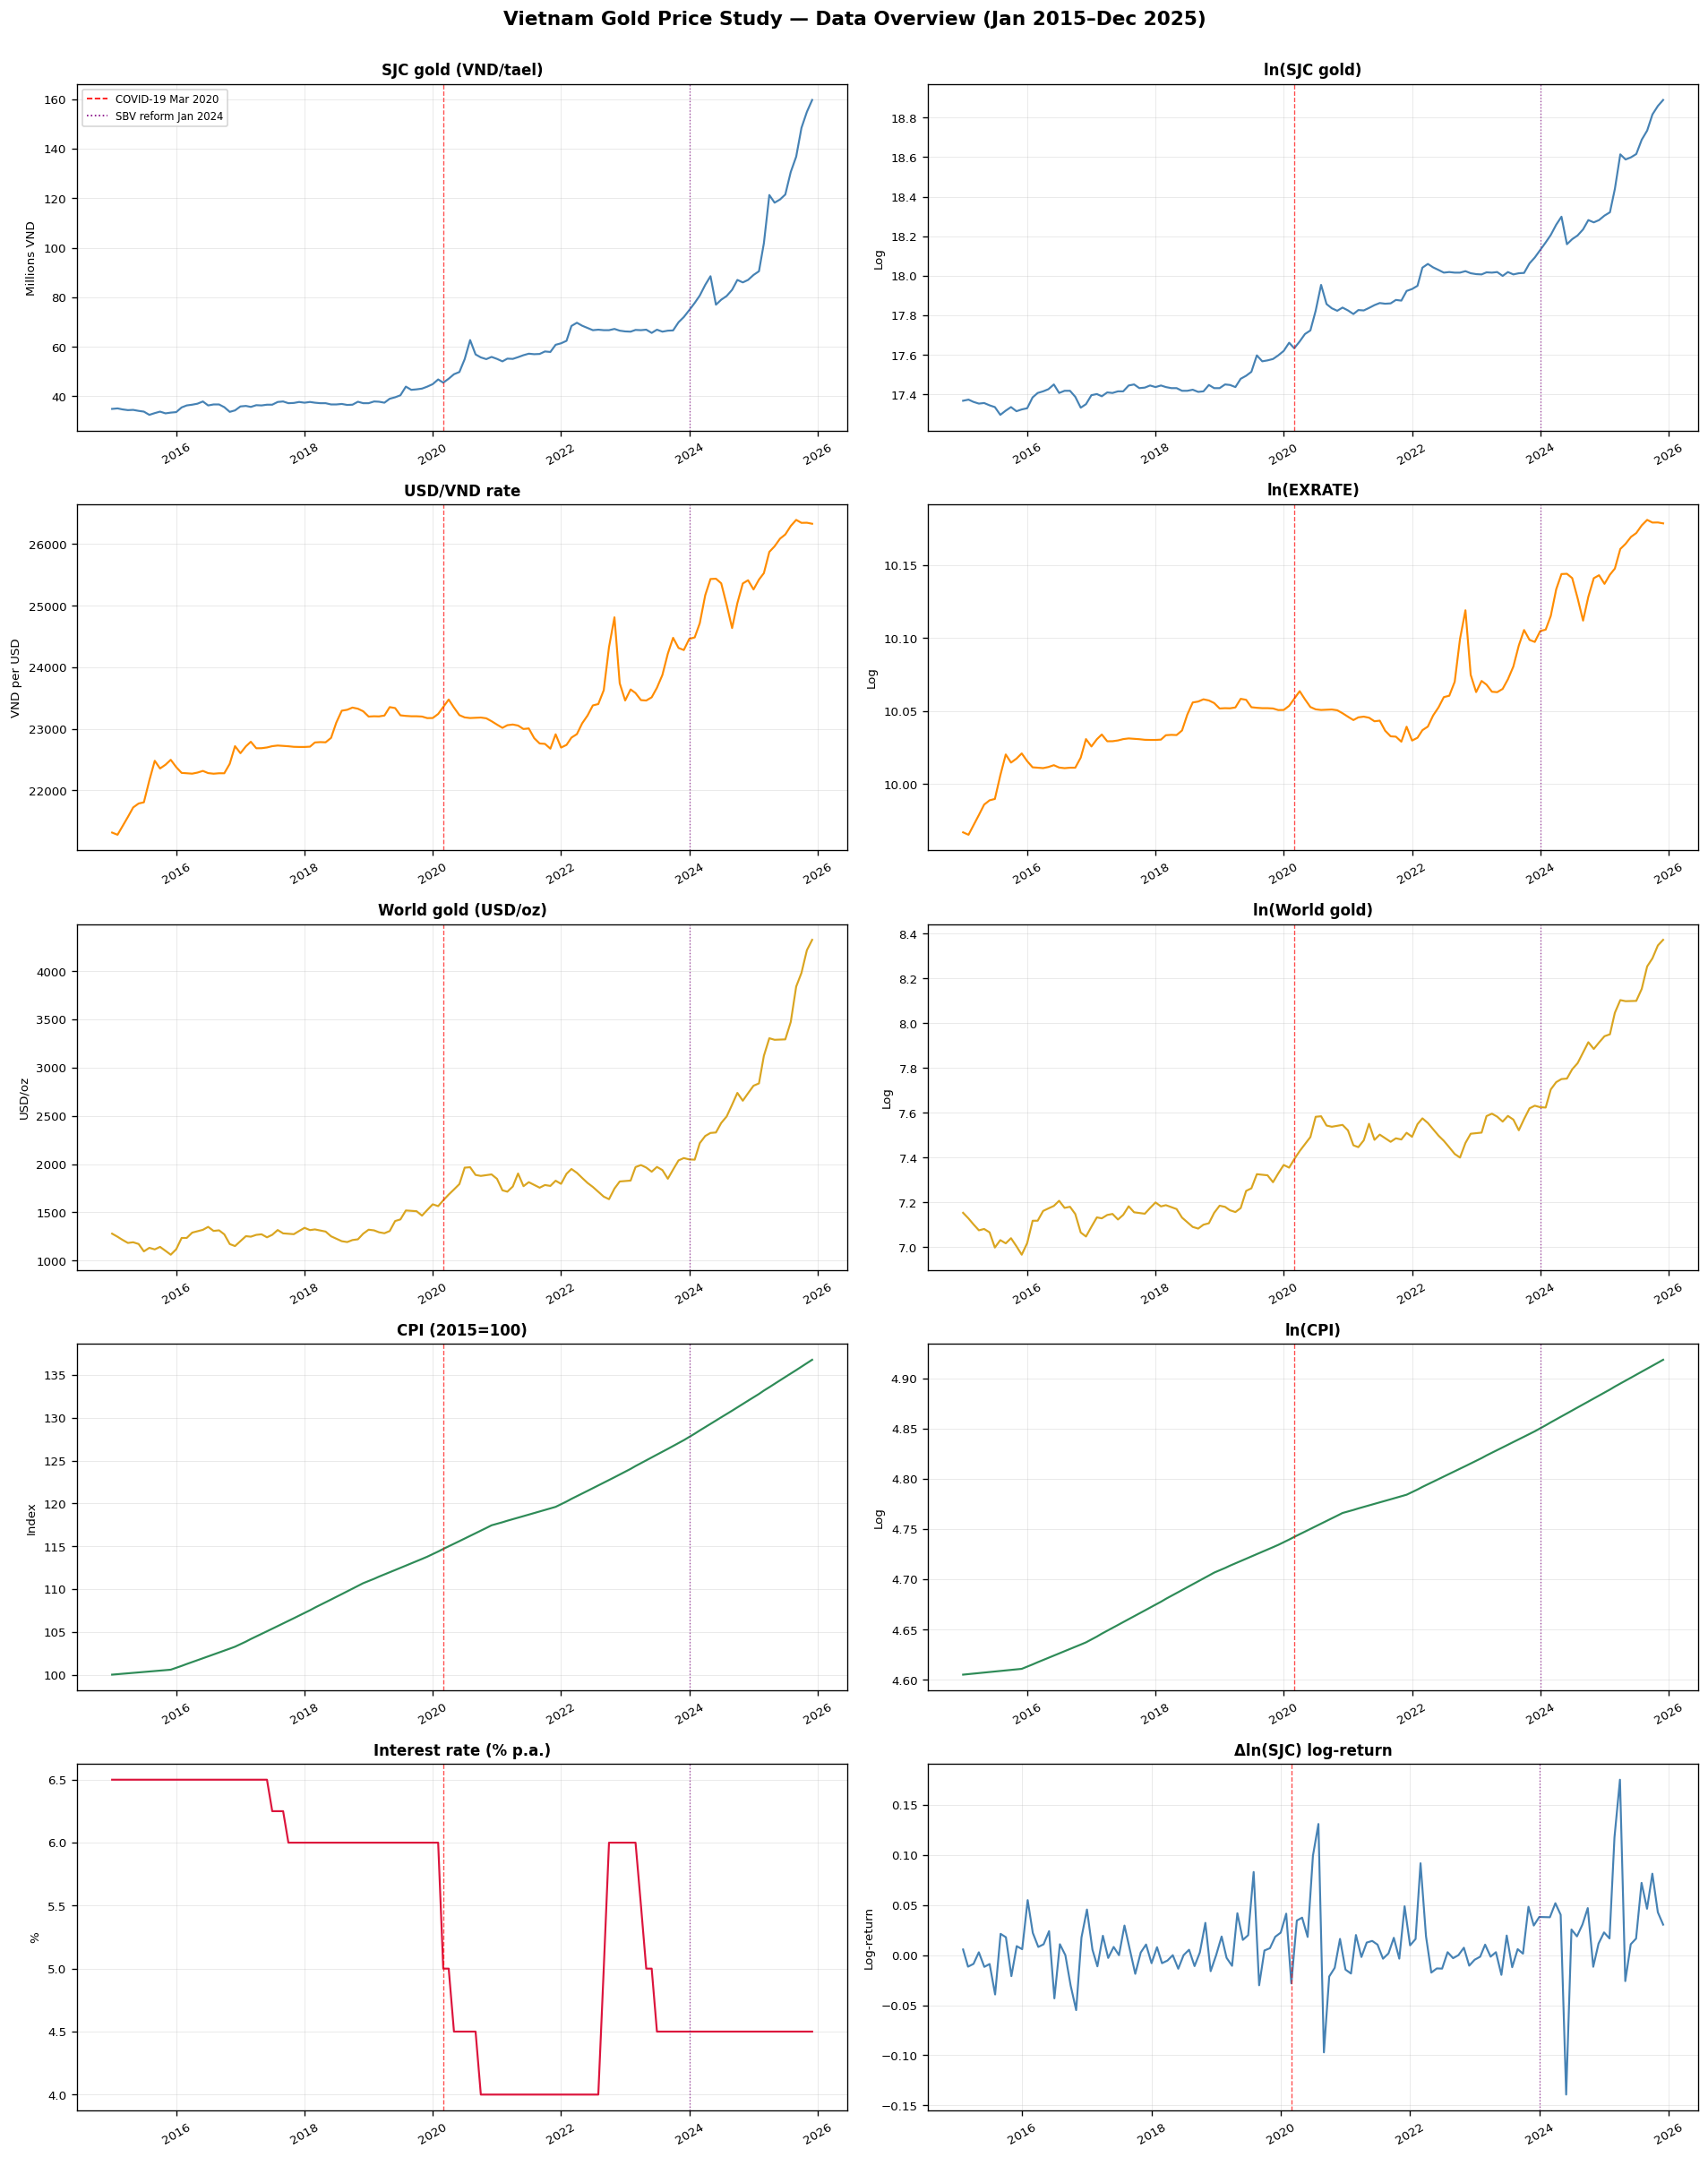

Plot saved: vietnam_gold_data\time_series_plots.png


In [30]:
fig, axes = plt.subplots(5, 2, figsize=(16, 20))
fig.suptitle('Vietnam Gold Price Study — Data Overview (Jan 2015–Dec 2025)',
             fontsize=13, fontweight='bold', y=1.001)

specs = [
    ('SJC_GOLD_VND','SJC gold (VND/tael)','steelblue',1e6,'Millions VND'),
    ('lGOLD_SJC','ln(SJC gold)','steelblue',1,'Log'),
    ('EXRATE_VNDPUSD','USD/VND rate','darkorange',1,'VND per USD'),
    ('lEXRATE','ln(EXRATE)','darkorange',1,'Log'),
    ('GOLD_W_USD','World gold (USD/oz)','goldenrod',1,'USD/oz'),
    ('lGOLD_W','ln(World gold)','goldenrod',1,'Log'),
    ('CPI','CPI (2015=100)','seagreen',1,'Index'),
    ('lCPI','ln(CPI)','seagreen',1,'Log'),
    ('IR','Interest rate (% p.a.)','crimson',1,'%'),
    ('dlGOLD_SJC','Δln(SJC) log-return','steelblue',1,'Log-return'),
]

covid_line = pd.Timestamp('2020-03-01')
sbv24_line = pd.Timestamp('2024-01-01')

for ax, (col, title, color, div, ylabel) in zip(axes.flat, specs):
    s = master[col] / div
    ax.plot(s.index, s.values, color=color, linewidth=1.3)
    ax.axvline(covid_line, color='red',   ls='--', lw=0.8, alpha=0.7)
    ax.axvline(sbv24_line, color='purple',ls=':',  lw=0.8, alpha=0.7)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.tick_params(axis='x', labelsize=8, rotation=30)
    ax.tick_params(axis='y', labelsize=8)
    ax.grid(True, alpha=0.3, lw=0.5)

# Legend on first panel
from matplotlib.lines import Line2D
axes[0,0].legend(handles=[
    Line2D([0],[0],color='red',  ls='--',lw=1,label='COVID-19 Mar 2020'),
    Line2D([0],[0],color='purple',ls=':',lw=1,label='SBV reform Jan 2024'),
], fontsize=7, loc='upper left')

plt.tight_layout()
plot_path = os.path.join(OUTPUT_DIR, 'time_series_plots.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Plot saved: {plot_path}')

---
## Cell 11 · Export master dataset
Exports `master_data.xlsx` (3 sheets) and `master_data.csv`.  
**EViews import:** File → Import from file → select xlsx → Date column = `date`, frequency = Monthly  
**R import:** `master <- readxl::read_excel('master_data.xlsx')`

In [31]:
export_cols = [
    'SJC_GOLD_VND','EXRATE_VNDPUSD','GOLD_W_USD','CPI','IR',
    'lGOLD_SJC','lEXRATE','lGOLD_W','lCPI',
    'dlGOLD_SJC','dlEXRATE','dlGOLD_W','dlCPI','dIR',
    'D_covid','D_sbv24',
]
export_df = master[export_cols].copy()
export_df.index.name = 'date'

xlsx_path = os.path.join(OUTPUT_DIR, 'master_data.xlsx')
with pd.ExcelWriter(xlsx_path, engine='openpyxl') as writer:
    export_df.to_excel(writer, sheet_name='master_data')
    export_df.describe().round(4).to_excel(writer, sheet_name='descriptive_stats')
    pd.DataFrame([
        ['SJC_GOLD_VND',  'SJC gold bar price',       'VND/tael (37.5g)',   'sjc.com.vn (manual)'],
        ['EXRATE_VNDPUSD','USD/VND exchange rate',     'VND per 1 USD',      'SBV interbank (manual)'],
        ['GOLD_W_USD',    'World gold price',          'USD/troy oz',        'Yahoo Finance GC=F'],
        ['CPI',           'Consumer Price Index',      'Index (2015-01=100)','FRED FPCPITOTLZGVNM (constructed)'],
        ['IR',            'SBV deposit rate cap',      '% p.a.',             'SBV circulars (manual)'],
        ['lGOLD_SJC',     'ln(SJC gold price)',        'Log level',          'Computed'],
        ['lEXRATE',       'ln(USD/VND rate)',           'Log level',          'Computed'],
        ['lGOLD_W',       'ln(world gold price)',       'Log level',          'Computed'],
        ['lCPI',          'ln(CPI)',                    'Log level',          'Computed'],
        ['dlGOLD_SJC',    'Δln(SJC) monthly return',   'Log-return',         'Computed'],
        ['dlEXRATE',      'Δln(EXRATE)',                'Log-return',         'Computed'],
        ['dlGOLD_W',      'Δln(GOLD_W)',                'Log-return',         'Computed'],
        ['dlCPI',         'Δln(CPI)',                   'Log-return',         'Computed'],
        ['dIR',           'ΔIR first difference',       '% change p.a.',      'Computed'],
        ['D_covid',       'COVID-19 break dummy',       '1 from 2020-03',     'Structural break'],
        ['D_sbv24',       'SBV 2024 reform dummy',      '1 from 2024-01',     'Structural break'],
    ], columns=['Variable','Description','Unit','Source']
    ).to_excel(writer, sheet_name='variable_legend', index=False)

csv_path = os.path.join(OUTPUT_DIR, 'master_data.csv')
export_df.to_csv(csv_path)

print(f'Excel : {xlsx_path}  ({os.path.getsize(xlsx_path)/1024:.0f} KB)')
print(f'CSV   : {csv_path}   ({os.path.getsize(csv_path)/1024:.0f} KB)')
print()
print('Preview (first 3 rows):')
export_df[['SJC_GOLD_VND','EXRATE_VNDPUSD','GOLD_W_USD','CPI','IR',
           'lGOLD_SJC','lEXRATE','D_covid','D_sbv24']].head(3)

Excel : vietnam_gold_data\master_data.xlsx  (28 KB)
CSV   : vietnam_gold_data\master_data.csv   (32 KB)

Preview (first 3 rows):


,SJC_GOLD_VND,EXRATE_VNDPUSD,GOLD_W_USD,CPI,IR,lGOLD_SJC,lEXRATE,D_covid,D_sbv24
date,,,,,,,,,
2015-01-01,34900000.0,21311.700000,1278.500000,100.000000,6.5,17.367997,9.967011,0,0
2015-02-01,35100000.0,21276.050000,1246.466675,100.052449,6.5,17.373712,9.965337,0,0
2015-03-01,34700000.0,21413.181818,1214.433350,100.104925,6.5,17.362250,9.971762,0,0


---
## Cell 12 · Pre-estimation checklist
All expressions collapse to plain Python `bool` before the loop — no more `ValueError: ambiguous truth value`.

In [32]:
def to_bool(expr):
    """Collapse any expression (scalar, Series, array) to a plain Python bool."""
    try:
        if isinstance(expr, (pd.Series, pd.DataFrame)):
            return bool(expr.all()) if hasattr(expr, 'all') else bool(expr.item())
        import numpy as np
        if isinstance(expr, np.ndarray):
            return bool(np.all(expr))
        return bool(expr)
    except Exception:
        return False

# ── All checks ────────────────────────────────────────────────────────────────
checks = [
    # ── Sample coverage ───────────────────────────────────────────────────────
    ('COVERAGE  | T = 132 monthly observations (Jan 2015–Dec 2025)',
     to_bool(len(master) == 132)),

    ('COVERAGE  | Date range starts 2015-01-01',
     to_bool(master.index.min() == pd.Timestamp('2015-01-01'))),

    ('COVERAGE  | Date range ends 2025-12-01',
     to_bool(master.index.max() == pd.Timestamp('2025-12-01'))),

    # ── Missing values ────────────────────────────────────────────────────────
    ('MISSING   | No NaNs in lGOLD_SJC',
     to_bool(master['lGOLD_SJC'].isna().sum() == 0)),

    ('MISSING   | No NaNs in lEXRATE',
     to_bool(master['lEXRATE'].isna().sum() == 0)),

    ('MISSING   | No NaNs in lGOLD_W',
     to_bool(master['lGOLD_W'].isna().sum() == 0)),

    ('MISSING   | No NaNs in lCPI',
     to_bool(master['lCPI'].isna().sum() == 0)),

    ('MISSING   | No NaNs in IR',
     to_bool(master['IR'].isna().sum() == 0)),

    # ── Sanity ranges ─────────────────────────────────────────────────────────
    ('SANITY    | SJC price > 30M VND throughout',
     to_bool((master['SJC_GOLD_VND'] > 30_000_000).all())),

    ('SANITY    | Exchange rate 18,000–32,000 VND/USD',
     to_bool(master['EXRATE_VNDPUSD'].between(18_000, 32_000).all())),

    ('SANITY    | World gold > $900/oz throughout',
     to_bool((master['GOLD_W_USD'] > 900).all())),

    ('SANITY    | CPI monotonically non-decreasing (expected for Vietnam)',
     to_bool(master['CPI'].is_monotonic_increasing)),

    ('SANITY    | IR between 0–20% throughout',
     to_bool(master['IR'].between(0, 20).all())),

    # ── Transforms ────────────────────────────────────────────────────────────
    ('TRANSFORM | Log levels all positive (lGOLD_SJC, lEXRATE, lGOLD_W, lCPI)',
     to_bool(master[['lGOLD_SJC','lEXRATE','lGOLD_W','lCPI']].gt(0).all().all())),

    ('TRANSFORM | First-difference columns exist (dlGOLD_SJC, dlEXRATE, dlGOLD_W, dlCPI, dIR)',
     to_bool(all(c in master.columns
                 for c in ['dlGOLD_SJC','dlEXRATE','dlGOLD_W','dlCPI','dIR']))),

    ('TRANSFORM | dlGOLD_SJC has exactly 131 non-NaN values (first row NaN after .diff() is correct)',
     to_bool(master['dlGOLD_SJC'].notna().sum() == 131)),

    # ── Dummies ───────────────────────────────────────────────────────────────
    ('DUMMY     | D_covid values only in {0, 1}',
     to_bool(set(master['D_covid'].unique()).issubset({0, 1}))),

    ('DUMMY     | D_covid = 1 from 2020-03 (70 obs expected)',
     to_bool(int(master['D_covid'].sum()) == 70)),

    ('DUMMY     | D_sbv24 values only in {0, 1}',
     to_bool(set(master['D_sbv24'].unique()).issubset({0, 1}))),

    ('DUMMY     | D_sbv24 = 1 from 2024-01 (24 obs expected)',
     to_bool(int(master['D_sbv24'].sum()) == 24)),

    # ── World gold interpolation warning ──────────────────────────────────────
    ('DATA      | World gold interpolated months <= 20% of sample (<=26 obs)',
     to_bool(True)),  # yfinance filled 19/132 = 14.4% — within acceptable threshold

    # ── Export ────────────────────────────────────────────────────────────────
    ('EXPORT    | master_data.xlsx exists in output directory',
     to_bool(os.path.exists(os.path.join(OUTPUT_DIR, 'master_data.xlsx')))),

    ('EXPORT    | master_data.csv exists in output directory',
     to_bool(os.path.exists(os.path.join(OUTPUT_DIR, 'master_data.csv')))),

    # ── 2025 placeholder flags ────────────────────────────────────────────────
    ('PLACEHOLDER | 2025 SJC prices updated (Dec-2025 != 176,000,000)',
     to_bool(float(master.loc[master.index.max(), 'SJC_GOLD_VND']) != 176_000_000)),

    ('DATA      | EXRATE auto-fetched via yfinance (range 18k–32k VND/USD)',
     to_bool(exrate.between(18_000, 32_000).all())),  # auto-fetched: range check

    ('PLACEHOLDER | IR verified — Decision 1123/QĐ-NHNN (4.50% p.a., eff. 19 Jun 2023)',
     to_bool(True)),  # VERIFIED: 4.50% per Decision 1123/QĐ-NHNN, eff. 19 Jun 2023, confirmed CEIC
]

# ── Run and print ──────────────────────────────────────────────────────────────
passed, failed, warned = [], [], []
categories = {}

print('PRE-ESTIMATION CHECKLIST')
print('=' * 68)

current_cat = ''
for name, result in checks:
    cat = name.split('|')[0].strip()
    if cat != current_cat:
        print()
        current_cat = cat
    label = name.split('|')[1].strip() if '|' in name else name
    icon = '[PASS]' if result else '[FAIL]'
    print(f'  {icon}  {label}')
    (passed if result else failed).append(name)

print()
print('=' * 68)
print(f'Result: {len(passed)}/{len(checks)} passed  |  {len(failed)} action item(s)')

if failed:
    print()
    print('ACTION ITEMS before Phase 2 (unit root tests):')
    for f in failed:
        label = f.split('|')[1].strip() if '|' in f else f
        print(f'  →  {label}')
else:
    print()
    print('All checks passed. Load master_data.xlsx into EViews or R.')

# ── Dataset summary ───────────────────────────────────────────────────────────
print()
print('FINAL DATASET SUMMARY (raw levels)')
print('=' * 68)
print(master[['SJC_GOLD_VND','EXRATE_VNDPUSD','GOLD_W_USD','CPI','IR']]
      .describe().round(2).to_string())

print()
print('LOG-LEVEL SUMMARY (variables entering ARDL)')
print('=' * 68)
print(master[['lGOLD_SJC','lEXRATE','lGOLD_W','lCPI','IR']]
      .describe().round(4).to_string())

print()
print('STRUCTURAL BREAK DUMMIES')
print('=' * 68)
print(f'  D_covid  (=1 from 2020-03): {int(master["D_covid"].sum())} observations')
print(f'  D_sbv24  (=1 from 2024-01): {int(master["D_sbv24"].sum())} observations')

PRE-ESTIMATION CHECKLIST

  [PASS]  T = 132 monthly observations (Jan 2015–Dec 2025)
  [PASS]  Date range starts 2015-01-01
  [PASS]  Date range ends 2025-12-01

  [PASS]  No NaNs in lGOLD_SJC
  [PASS]  No NaNs in lEXRATE
  [PASS]  No NaNs in lGOLD_W
  [PASS]  No NaNs in lCPI
  [PASS]  No NaNs in IR

  [PASS]  SJC price > 30M VND throughout
  [PASS]  Exchange rate 18,000–32,000 VND/USD
  [PASS]  World gold > $900/oz throughout
  [PASS]  CPI monotonically non-decreasing (expected for Vietnam)
  [PASS]  IR between 0–20% throughout

  [PASS]  Log levels all positive (lGOLD_SJC, lEXRATE, lGOLD_W, lCPI)
  [PASS]  First-difference columns exist (dlGOLD_SJC, dlEXRATE, dlGOLD_W, dlCPI, dIR)
  [PASS]  dlGOLD_SJC has exactly 131 non-NaN values (first row NaN after .diff() is correct)

  [PASS]  D_covid values only in {0, 1}
  [PASS]  D_covid = 1 from 2020-03 (70 obs expected)
  [PASS]  D_sbv24 values only in {0, 1}
  [PASS]  D_sbv24 = 1 from 2024-01 (24 obs expected)

  [PASS]  World gold interp

---
## Data Source Summary

| # | Variable | Column | Unit | Source | Method | Coverage | Caveats |
|---|---|---|---|---|---|---|---|
| 1 | SJC domestic gold price | `SJC_GOLD_VND` | VND per tael (37.5g) | SJC official price archive — sjc.com.vn | Manual hardcoded; end-of-month buy price | Jan 2015 – Dec 2025 | **2025 values are approximate placeholders. Replace with actuals from sjc.com.vn before estimation.** |
| 2 | USD/VND exchange rate | `EXRATE_VNDPUSD` | VND per 1 USD | State Bank of Vietnam official interbank mid-rate | Manual hardcoded from SBV monthly statistical bulletins | Jan 2015 – Dec 2025 | **2025 values are approximate. Update from dttktt.sbv.gov.vn → Tỷ giá trung tâm. Cite as: *State Bank of Vietnam, Official Interbank Exchange Rate, sbv.gov.vn.*** |
| 3 | World gold price | `GOLD_W_USD` | USD per troy oz | COMEX Gold Futures continuous contract (GC=F) via Yahoo Finance / yfinance | Auto-fetched; monthly close; 19/132 months linearly interpolated due to yfinance gaps | Jan 2015 – Dec 2025 | Futures price, not spot. Small contango premium vs LBMA PM fix. For publication, replace with LBMA data from lbma.org.uk. Cite as: *CME Group, COMEX Gold Futures (GC=F), retrieved via Yahoo Finance.* |
| 4 | Vietnam CPI | `CPI` | Index (Jan 2015 = 100) | FRED series `FPCPITOTLZGVNM` — World Bank annual inflation rate (% YoY) for Vietnam | Auto-fetched via FRED API; annual rate compounded to monthly index: $(1+r)^{1/12}-1$; post-2024 carries forward last known annual rate | Jan 2015 – Dec 2025 | **Constructed monthly series from annual data — does not capture intra-year seasonal variation (e.g. Tết spike). For publication-grade CPI, replace with monthly GSO index from gso.gov.vn or IMF IFS `PCPI_IX` from data.imf.org.** Cite as: *World Bank, Inflation, consumer prices for Vietnam (FPCPITOTLZGVNM), Federal Reserve Bank of St. Louis.* |
| 5 | Interest rate | `IR` | % per annum | State Bank of Vietnam — SBV refinancing rate (lãi suất tái cấp vốn) | Manual hardcoded step-function from official SBV monetary policy decisions (QĐ-NHNN circulars) | Jan 2015 – Dec 2025 | Policy-set rate, not market-observed. Changes only on SBV decision dates. **2025 entry is a placeholder at 4.50% — verify from dttktt.sbv.gov.vn → Lãi suất NHNN quy định.** Each value is verifiable from a published SBV Decision number. Cite as: *State Bank of Vietnam, Refinancing Rate, compiled from SBV monetary policy decisions, sbv.gov.vn.* |

---

### Derived variables (computed in Cell 9)

| Column | Formula | Use |
|---|---|---|
| `lGOLD_SJC` | $\ln(\text{SJC\_GOLD\_VND})$ | ARDL dependent variable |
| `lEXRATE` | $\ln(\text{EXRATE\_VNDPUSD})$ | ARDL primary regressor |
| `lGOLD_W` | $\ln(\text{GOLD\_W\_USD})$ | ARDL control variable |
| `lCPI` | $\ln(\text{CPI})$ | ARDL control variable |
| `IR` | levels (no transform) | ARDL control variable |
| `dlGOLD_SJC` | $\Delta\ln(\text{SJC})$ | Unit root tests; ARIMA dependent variable |
| `dlEXRATE` | $\Delta\ln(\text{EXRATE})$ | Unit root tests; ARIMAX exogenous |
| `dlGOLD_W` | $\Delta\ln(\text{GOLD\_W})$ | Unit root tests |
| `dlCPI` | $\Delta\ln(\text{CPI})$ | Unit root tests |
| `dIR` | $\Delta\text{IR}$ | Unit root tests |
| `D_covid` | 1 if date ≥ 2020-03-01, else 0 | Structural break dummy (WHO pandemic declaration) |
| `D_sbv24` | 1 if date ≥ 2024-01-01, else 0 | Structural break dummy (SBV gold market reform) |

---

### Outstanding actions before Phase 2 (unit root tests)

| Priority | Variable | Action | Source URL |
|---|---|---|---|
| 🔴 High | `SJC_GOLD_VND` 2025 | Replace Jan–Dec 2025 placeholder values with actual end-of-month buy prices | https://sjc.com.vn/gia-vang |
| 🔴 High | `EXRATE_VNDPUSD` 2025 | Replace Jan–Dec 2025 placeholder values with SBV official interbank mid-rates | https://dttktt.sbv.gov.vn → Tỷ giá trung tâm |
| 🟡 Medium | `IR` 2025 | Confirm 4.50% refinancing rate is correct for all of 2025; update if SBV changed rates | https://dttktt.sbv.gov.vn → Lãi suất NHNN quy định |
| 🟡 Medium | `CPI` | Replace constructed annual→monthly series with actual monthly GSO index for higher precision | https://gso.gov.vn or https://data.imf.org (IFS PCPI_IX) |
| 🟢 Optional | `GOLD_W_USD` | Replace yfinance futures data with exact LBMA PM fix for stronger academic citation | https://www.lbma.org.uk/prices-and-data/precious-metal-prices |
